In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# 1) Create noisy signal: 10 Hz sine + 100 Hz sine noise
fs = 1000  
t = np.arange(0, 1.0, 1/fs)

signal_10hz = np.sin(2 * np.pi * 10 * t)
noise_100hz = 0.5 * np.sin(2 * np.pi * 100 * t)
noisy_signal = signal_10hz + noise_100hz

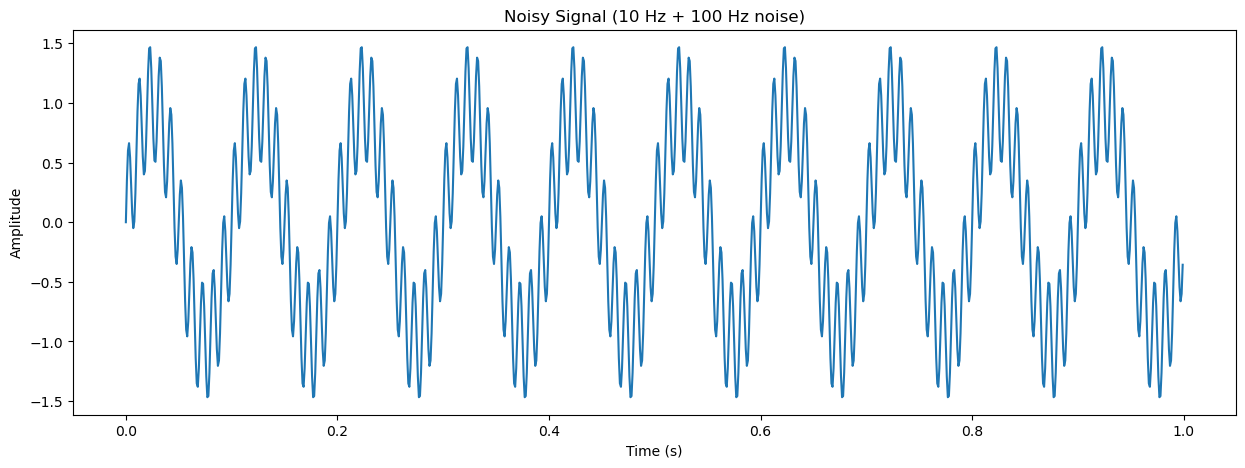

In [9]:
# Show noisy signal
plt.figure(figsize=(15, 5))
plt.plot(t, noisy_signal)
plt.title('Noisy Signal (10 Hz + 100 Hz noise)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

In [ ]:
# Manual Hamming window (no np.hamming)
def manual_hamming(N):
    w = np.zeros(N)
    for n in range(N):
        w[n] = 0.54 - 0.46 * np.cos(2 * np.pi * n / (N - 1))
    return w

In [ ]:
# Manual sum function
def manual_sum(arr):
    s = 0
    for x in arr:
        s += x
    return s

In [ ]:
# 2) Design low-pass FIR filter (cutoff = 20 Hz) using Hamming window
fc = 20
num_taps = 101
M = num_taps - 1
n = np.arange(num_taps)

# Ideal low-pass impulse response (windowed-sinc method)
h_ideal = 2 * (fc / fs) * np.sin(2 * (fc / fs) * (n - M / 2))
window = manual_hamming(num_taps)
h = h_ideal * window
h = h / manual_sum(h)

In [ ]:
# 3) Manual convolution function (no np.convolve)
def manual_convolve_same(x, h):
    nx = len(x)
    nh = len(h)
    nfull = nx + nh - 1
    
    # Full linear convolution
    y_full = np.zeros(nfull)
    for i in range(nx):
        for j in range(nh):
            y_full[i + j] += x[i] * h[j]
    
    # Extract 'same' length (center part)
    start = (nh - 1) // 2
    end = start + nx
    return y_full[start:end]

In [ ]:
# Filter the noisy signal using manual convolution
filtered_signal = manual_convolve_same(noisy_signal, h)

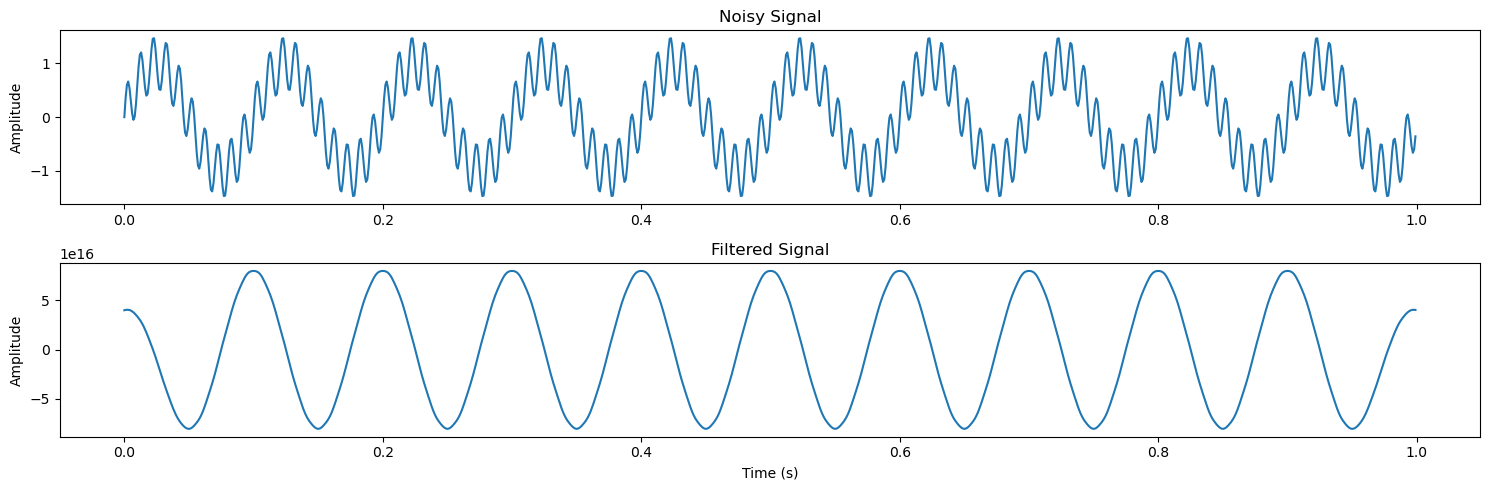

In [12]:
# 4) Plot noisy and filtered signals
plt.figure(figsize=(15, 5))

plt.subplot(2, 1, 1)
plt.plot(t, noisy_signal)
plt.title('Noisy Signal')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(t, filtered_signal)
plt.title('Filtered Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()